# Analysis
## Prep

In [22]:
# Import necessary libraries
from datetime import datetime, timedelta

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os
import json

plt.rcParams['font.family'] = 'serif'
plt.rcParams["font.serif"] = ["Times New Roman"]


# Load our results
with open(os.path.join("..", "dataset", "v", "results.json"), "r", encoding="utf-8") as f:
    data = json.load(f)

def time_to_seconds(time_str) -> int:
    """
    Converts a time string in 'MM:SS' format to total seconds.
    """
    try:
        # Detect format based on number of colons
        if time_str.count(':') == 1:
            fmt = "%M:%S"
        else:
            raise ValueError("Invalid time format")
        
        dt = datetime.strptime(time_str, fmt)
        # Convert to total seconds
        td = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second)
        return int(td.total_seconds())
    except ValueError:
        raise ValueError("Invalid time string. Use 'MM:SS' format")


## Claim #2

In [23]:

rows_2nd_claim = []

for record in data:
    last = record["DetectionResults"][-1]
    rows_2nd_claim.append({
        "Id": record["Id"],
        "Is": record["Is"],
        "Human": 1 if record["HumanClassification"] == "Fraud" else 0,
        "Naive": 1 if last["NaiveClassification"]["Flag"] == "Fraud" else 0,
        "Enhanced": 1 if last["EnhancedClassification"]["Flag"] == "Fraud" else 0,
        "Duration-mean": time_to_seconds(record["RealDuration"]),
        "Duration-median": time_to_seconds(record["RealDuration"])
    })

df2 = pd.DataFrame(rows_2nd_claim)
groupby_2nd_claim = df2.groupby("Is").aggregate({
    "Id": "count",
    "Human": "sum",
    "Naive": "sum",
    "Enhanced": "sum",
    "Duration-mean": "mean",
    "Duration-median": "median",
})
groupby_2nd_claim.columns = ['Total', 'Human', 'Naive', 'Enhanced', 'Duration (mean)', 'Duration (median)']
result_2nd_claim = groupby_2nd_claim.round(decimals=2)
print (result_2nd_claim)


       Total  Human  Naive  Enhanced  Duration (mean)  Duration (median)
Is                                                                      
Fraud    101     24     65        52           115.31              106.0


## Claim #4 

In [24]:
rows_4th_claim = []

for record in data:
    for subrecord in record["DetectionResults"]:
        rows_4th_claim.append({
            "Id": record["Id"],
            "Naive": subrecord["NaiveClassification"]["Duration"],
            "Enhanced": subrecord["EnhancedClassification"]["Duration"]
        })

df4 = pd.DataFrame(rows_4th_claim)
df4.describe().round(2)

,Naive,Enhanced
count,1186.00,1186.00
mean,5.02,9.76
std,2.90,3.49
min,1.26,2.69
25%,3.14,7.47
50%,4.14,9.70
75%,5.75,11.94
max,23.19,27.86


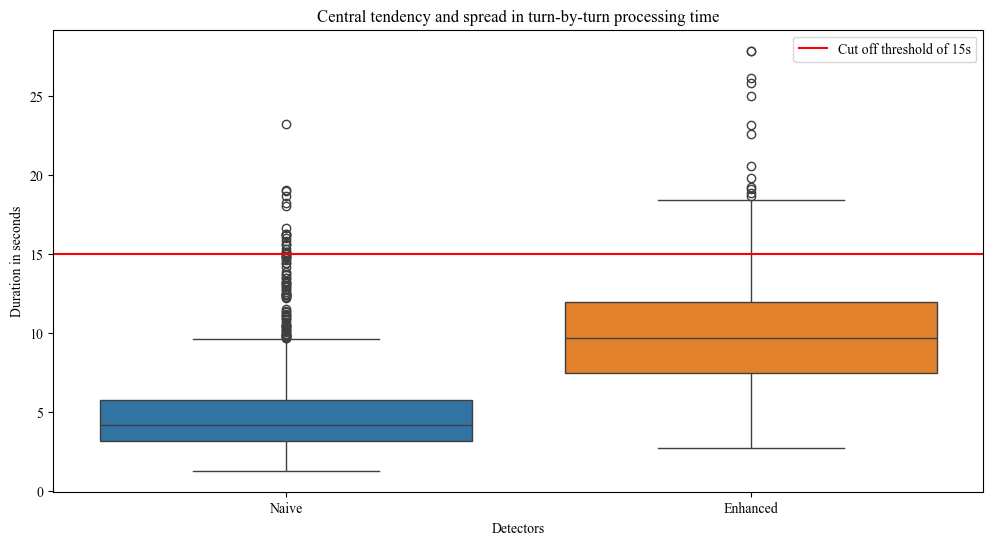

In [25]:
# Boxplot to identify outliers
plt.figure(figsize=(12, 6))
bxp = sns.boxplot(data=df4.drop('Id', axis=1))
ax = plt.subplot(111)
ax.axhline(y = 15, color = 'r', label = 'Cut off threshold of 15s')
ax.set_xlabel("Detectors")
ax.set_ylabel("Duration in seconds")
plt.legend()
plt.title('Central tendency and spread in turn-by-turn processing time')
plt.show()

### What does all those outliers tell us?

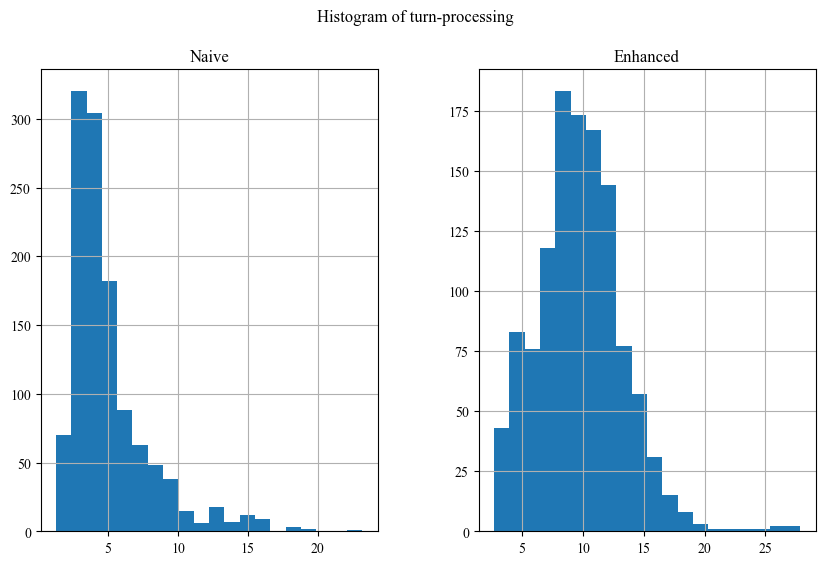

In [26]:
# Histogram for each feature
hist = df4.drop('Id', axis=1).hist(figsize=(10, 6), bins=20)
plt.suptitle('Histogram of turn-processing')
plt.show()

## Claim 2

In [44]:
def aggregate_prediction(detection_results, model_key):
    """
    Rule: if the last utterance is Fraud then it is Fraud. Otherwise is safe.
    """
    if detection_results[-1][model_key]["Flag"] == "Fraud":
        return "Fraud"
    return "Safe"

def compute_metrics(calls, predictor_fn):
    TP = FP = TN = FN = 0

    for call in calls:
        y_true = call["Is"] # ground truth
        y_pred = predictor_fn(call) 

        if y_true == "Fraud" and y_pred == "Fraud":
            TP += 1
        elif y_true == "Safe" and y_pred == "Fraud":
            FP += 1
        elif y_true == "Safe" and y_pred == "Safe":
            TN += 1
        elif y_true == "Fraud" and y_pred == "Safe":
            FN += 1

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = (
        (2 * precision * recall) / (precision + recall)
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "TP": TP,
        "FP": FP,
        "TN": TN,
        "FN": FN
    }


def naive_predictor(json_data):
    return aggregate_prediction(
        json_data["DetectionResults"],
        "NaiveClassification"
    )

def enhanced_predictor(json_data):
    return aggregate_prediction(
        json_data["DetectionResults"],
        "EnhancedClassification"
    )

def human_predictor(json_data):
    return json_data["HumanClassification"]

results = {
    "Naive": [],
    "Enhanced": [],
    "Human": []
}

metrics_naive = compute_metrics(data, naive_predictor)
metrics_enhanced = compute_metrics(data, enhanced_predictor)
metrics_human = compute_metrics(data, human_predictor)

def average_metrics(metrics_list):
    return {
        k: sum(m[k] for m in metrics_list) / len(metrics_list)
        for k in metrics_list[0]
    }

df3 = pd.DataFrame(
    [metrics_naive, metrics_enhanced, metrics_human],
    index=["Naive", "Enhanced", "Trained human"]
)[["Accuracy", "Precision", "Recall", "F1-score"]]
print(df3)

               Accuracy  Precision    Recall  F1-score
Naive          0.643564        1.0  0.643564  0.783133
Enhanced       0.514851        1.0  0.514851  0.679739
Trained human  0.237624        1.0  0.237624  0.384000
